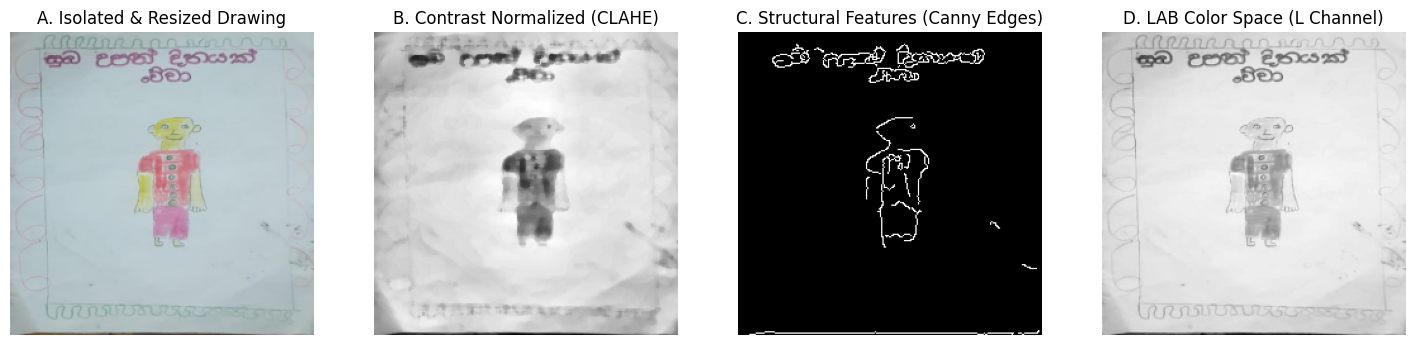

In [1]:
# ============================================================
# FULL PREPROCESSING PIPELINE FOR CHILDREN'S DRAWING ANALYSIS
# (PyCharm / Jupyter Notebook Compatible – Single Cell)
# ============================================================

# -----------------------------
# 1. IMPORT REQUIRED LIBRARIES
# -----------------------------
# OpenCV: Image processing operations
# NumPy: Numerical and array operations
# Matplotlib: Visualization of preprocessing outputs

import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 2. DEFINE MODEL INPUT SIZE
# -----------------------------
# All processed images are resized to a fixed resolution
# to ensure consistency across deep learning models
TARGET_SIZE = (240, 240)

# -------------------------------------------------------
# 3. ISOLATION + PREPROCESSING FUNCTION (6-STEP PIPELINE)
# -------------------------------------------------------
def isolate_and_preprocess_drawing(image_data, target_size=TARGET_SIZE):
    """
    Performs the complete preprocessing pipeline:

    Step 1: Drawing detection & perspective correction
    Step 2: Resizing & grayscale conversion
    Step 3: Noise reduction using Median Blur
    Step 4: Contrast normalization using CLAHE
    Step 5: Structural feature extraction using Canny Edge Detection
    Step 6: Color feature preparation using LAB color space

    Returns:
        - Resized & isolated drawing (BGR)
        - Contrast-normalized grayscale image
        - Edge-detected image
        - LAB color space image
    """

    # -----------------------------
    # STEP 1: LOAD IMAGE FROM BYTES
    # -----------------------------
    # Image is decoded from raw bytes for consistency across platforms
    img_bgr = cv2.imdecode(np.frombuffer(image_data, np.uint8), cv2.IMREAD_COLOR)

    if img_bgr is None:
        print("Error: Image could not be decoded.")
        return None, None, None, None

    # Convert to grayscale for thresholding and contour detection
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to suppress noise and smooth edges
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Apply Otsu's thresholding to separate drawing from background
    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # -----------------------------
    # STEP 1A: CONTOUR DETECTION
    # -----------------------------
    # External contours are extracted to locate the drawing boundary
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Identify the largest 4-point contour (assumed drawing region)
    max_area = 0
    best_contour = None

    for c in contours:
        area = cv2.contourArea(c)
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        if area > max_area and len(approx) == 4:
            max_area = area
            best_contour = approx

    # -----------------------------
    # STEP 1B: PERSPECTIVE CORRECTION
    # -----------------------------
    # If a rectangular drawing boundary is detected, correct skew
    if best_contour is not None:
        pts = best_contour.reshape(4, 2)

        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]  # Top-left
        rect[2] = pts[np.argmax(s)]  # Bottom-right
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]  # Top-right
        rect[3] = pts[np.argmax(diff)]  # Bottom-left

        (tl, tr, br, bl) = rect

        width = int(max(
            np.linalg.norm(br - bl),
            np.linalg.norm(tr - tl)
        ))

        height = int(max(
            np.linalg.norm(tr - br),
            np.linalg.norm(tl - bl)
        ))

        dst = np.array([
            [0, 0],
            [width - 1, 0],
            [width - 1, height - 1],
            [0, height - 1]
        ], dtype="float32")

        M = cv2.getPerspectiveTransform(rect, dst)
        img_cropped = cv2.warpPerspective(img_bgr, M, (width, height))
    else:
        # If no clear boundary is found, use the entire image
        img_cropped = img_bgr

    # -----------------------------
    # STEP 2: RESIZE & GRAYSCALE
    # -----------------------------
    img_resized = cv2.resize(
        img_cropped, target_size, interpolation=cv2.INTER_AREA
    )
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # -----------------------------
    # STEP 3: NOISE REDUCTION
    # -----------------------------
    # Median filtering preserves edges while removing salt-and-pepper noise
    img_denoised = cv2.medianBlur(img_gray, 5)

    # -----------------------------
    # STEP 4: CONTRAST NORMALIZATION
    # -----------------------------
    # CLAHE improves visibility of faint strokes and uneven lighting
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_normalized = clahe.apply(img_denoised)

    # -----------------------------
    # STEP 5: EDGE DETECTION
    # -----------------------------
    # Canny extracts structural features useful for developmental analysis
    img_edges = cv2.Canny(img_normalized, 100, 200)

    # -----------------------------
    # STEP 6: COLOR SPACE CONVERSION
    # -----------------------------
    # LAB color space enables perceptually consistent emotion analysis
    img_lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)

    return img_resized, img_normalized, img_edges, img_lab


# -------------------------------------------------------
# 4. LOAD LOCAL IMAGE (PYCHARM COMPATIBLE)
# -------------------------------------------------------
image_path = "wood bg1.jpeg"  # Replace with your image path

with open(image_path, "rb") as f:
    image_data = f.read()

# Run preprocessing pipeline
img_original, img_normalized, img_edges, img_lab = \
    isolate_and_preprocess_drawing(image_data)

# -------------------------------------------------------
# 5. VISUALIZE PREPROCESSING OUTPUTS
# -------------------------------------------------------
if img_original is not None:

    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title("A. Isolated & Resized Drawing")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(img_normalized, cmap="gray")
    plt.title("B. Contrast Normalized (CLAHE)")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(img_edges, cmap="gray")
    plt.title("C. Structural Features (Canny Edges)")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(img_lab[:, :, 0], cmap="gray")
    plt.title("D. LAB Color Space (L Channel)")
    plt.axis("off")

    plt.show()
